In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [42]:
df = pd.read_csv('PJME_hourly.csv', parse_dates=['Datetime'])

In [43]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek 
df['month'] = df['Datetime'].dt.month
df['day'] = df['Datetime'].dt.day

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

print(df.head(880))

               Datetime  PJME_MW  hour  day_of_week  month  day  is_weekend
0   2002-12-31 01:00:00  26498.0     1            1     12   31           0
1   2002-12-31 02:00:00  25147.0     2            1     12   31           0
2   2002-12-31 03:00:00  24574.0     3            1     12   31           0
3   2002-12-31 04:00:00  24393.0     4            1     12   31           0
4   2002-12-31 05:00:00  24860.0     5            1     12   31           0
..                  ...      ...   ...          ...    ...  ...         ...
875 2002-11-25 12:00:00  32212.0    12            0     11   25           0
876 2002-11-25 13:00:00  31748.0    13            0     11   25           0
877 2002-11-25 14:00:00  31488.0    14            0     11   25           0
878 2002-11-25 15:00:00  31037.0    15            0     11   25           0
879 2002-11-25 16:00:00  30904.0    16            0     11   25           0

[880 rows x 7 columns]


In [45]:
df = df.sort_values('Datetime')

In [ ]:
# Lag features
lags = [1, 2, 3, 6, 12, 24, 48, 168]

for lag in lags:
    df[f'lag_{lag}'] = df['PJME_MW'].shift(lag)

# Rolling feature 
df['rolling_mean_24'] = df['PJME_MW'].shift(1).rolling(24).mean()

df = df.dropna()


In [47]:
df

,Datetime,PJME_MW,hour,day_of_week,month,day,is_weekend,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,rolling_mean_24
8566,2002-01-08 01:00:00,29445.0,1,1,1,8,0,31187.0,33579.0,35997.0,39581.0,35790.0,26862.0,27100.0,30393.0,33452.583333
8567,2002-01-08 02:00:00,28670.0,2,1,1,8,0,29445.0,31187.0,33579.0,38780.0,35594.0,25976.0,26097.0,29265.0,33560.208333
8568,2002-01-08 03:00:00,28375.0,3,1,1,8,0,28670.0,29445.0,31187.0,37777.0,35527.0,25641.0,25793.0,28357.0,33672.458333
8569,2002-01-08 04:00:00,28542.0,4,1,1,8,0,28375.0,28670.0,29445.0,35997.0,35489.0,25666.0,25657.0,27899.0,33786.375000
8570,2002-01-08 05:00:00,29261.0,5,1,1,8,0,28542.0,28375.0,28670.0,33579.0,36530.0,26328.0,25778.0,28057.0,33906.208333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140250,2018-08-02 20:00:00,44057.0,20,3,8,2,0,45641.0,46760.0,46816.0,46534.0,35645.0,46912.0,40289.0,46337.0,40021.875000
140251,2018-08-02 21:00:00,43256.0,21,3,8,2,0,44057.0,45641.0,46760.0,47154.0,37810.0,45985.0,39938.0,44542.0,39902.916667
140252,2018-08-02 22:00:00,41552.0,22,3,8,2,0,43256.0,44057.0,45641.0,46989.0,39902.0,44094.0,38610.0,42638.0,39789.208333
140253,2018-08-02 23:00:00,38500.0,23,3,8,2,0,41552.0,43256.0,44057.0,46816.0,42189.0,40666.0,35950.0,39276.0,39683.291667


In [48]:
# Target
target = 'PJME_MW'

# Split
split_date = '2018-01-01'

train = df[df['Datetime'] < split_date]
test = df[df['Datetime'] >= split_date]

X_train = train[['hour', 'day_of_week' , 'is_weekend' , 'month', 'day' ,     'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_12', 'lag_24',
    'lag_48', 'lag_168',
    'rolling_mean_24']]
y_train = train[target]

X_test = test[['hour', 'day_of_week' , 'is_weekend' , 'month', 'day' ,     'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_12', 'lag_24',
    'lag_48', 'lag_168',
    'rolling_mean_24']]
y_test = test[target]

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

Model = []
RMSE = []
R_sq = []

cv = TimeSeriesSplit(n_splits=5)

# Function
def input_scores(name, model, x, y):
    Model.append(name)

    # RMSE
    rmse = np.sqrt(
        -cross_val_score(
            model, x, y,
            cv=cv,
            scoring='neg_mean_squared_error'
        ).mean()
    )
    RMSE.append(rmse)

    # R2 Score
    r2 = cross_val_score(
        model, x, y,
        cv=cv,
        scoring='r2'
    ).mean()
    R_sq.append(r2)

In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from xgboost import XGBRegressor


names = ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
         'K Neighbors Regressor', 'Decision Tree Regressor', 
         'Random Forest Regressor', 'Gradient Boosting Regressor',
         'Adaboost Regressor' , 'XGBoost Regressor']
models = [LinearRegression(), Ridge(), Lasso(),
          KNeighborsRegressor(), DecisionTreeRegressor(),
          RandomForestRegressor(), GradientBoostingRegressor(), 
          AdaBoostRegressor() , XGBRegressor()]

#Running all algorithms
for name, model in zip(names, models):
    input_scores(name, model, X_train, y_train)

d:\LIVE TSF ENERGY PROJECT\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.793e+09, tolerance: 9.479e+07
  model = cd_fast.enet_coordinate_descent(
d:\LIVE TSF ENERGY PROJECT\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.736e+09, tolerance: 1.917e+08
  model = cd_fast.enet_coordinate_descent(
d:\LIVE TSF ENERGY PROJECT\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap

In [51]:
evaluation = pd.DataFrame({'Model': Model,
                           'RMSE': RMSE,
                           'R2': R_sq})
print("FOLLOWING ARE THE TRAINING SCORES: ")
evaluation

FOLLOWING ARE THE TRAINING SCORES: 


,Model,RMSE,R2
0,Linear Regression,602.076143,0.991237
1,Ridge Regression,602.076128,0.991237
2,Lasso Regression,602.292204,0.991231
3,K Neighbors Regressor,957.631235,0.977722
4,Decision Tree Regressor,558.023273,0.992399
5,Random Forest Regressor,384.462723,0.996408
6,Gradient Boosting Regressor,691.635284,0.988394
7,Adaboost Regressor,1350.956415,0.955899
8,XGBoost Regressor,403.601292,0.996070


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np

# TimeSeries CV
tscv = TimeSeriesSplit(n_splits=5)

# Model
xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [54]:
print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

Best Params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


In [55]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 320.77729483815045
R2: 0.9973902746005782


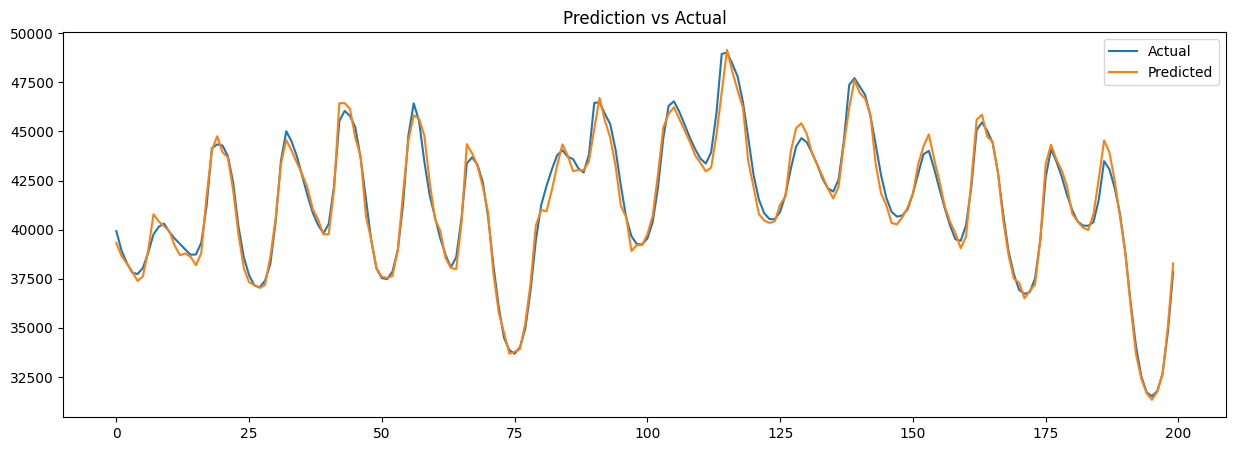

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

<Axes: >

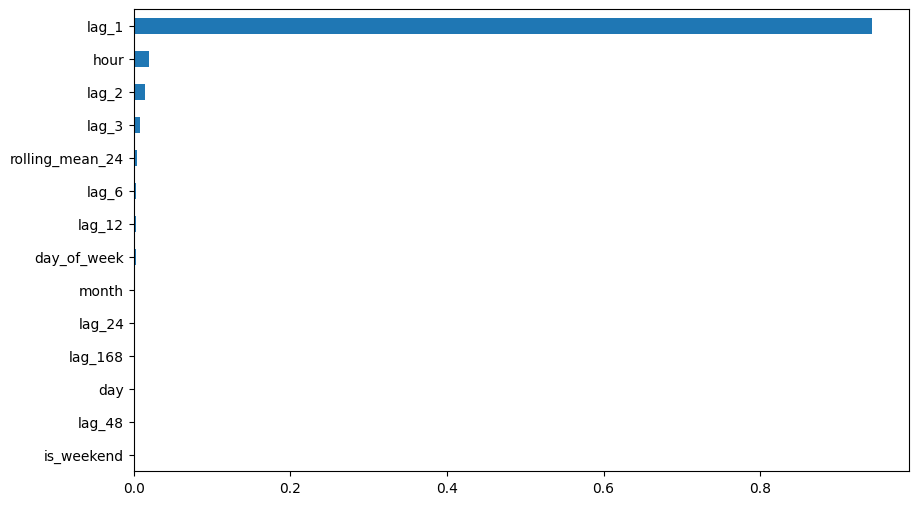

In [57]:
import pandas as pd

importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).sort_values()

feat_imp.plot(kind='barh', figsize=(10,6))

In [58]:
import joblib


joblib.dump(best_model, "energy_model.pkl")

['energy_model.pkl']